# Análisis de ventas y rentabilidad de un e-commerce

## Objetivo

Analizar la evolución de las ventas entre el primer y segundo semestre de 2025, no solo desde la facturación, sino también desde la rentabilidad del negocio.

El análisis busca responder:

> **Las ventas crecieron 30%. ¿Y si eso no fuera suficiente para decir que el negocio está mejor?**

A partir de los datos de clientes, productos, pedidos y detalle de pedidos, se analizarán indicadores como:

- Facturación
- Cantidad de pedidos
- Unidades vendidas
- Margen y margen %
- Desempeño por categoría
- Descuentos y comportamiento de los productos

El objetivo final es identificar **qué factores explican la evolución de la rentabilidad** y transformar los resultados en un análisis de negocio que luego pueda comunicarse mediante un dashboard en Power BI.

### Flujo de trabajo

**Python → exploración y análisis → identificación de hallazgos → Power BI → visualización y comunicación de resultados**

In [2]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [25]:
#Datasets local
clientes = pd.read_csv("../data/clientes.csv")
productos = pd.read_csv("../data/productos.csv")
pedidos = pd.read_csv("../data/pedidos.csv")
detalle = pd.read_csv("../data/detalle_pedidos.csv")

In [26]:
# Primera inspeccion de los datos
for nombre, df in {
    "clientes": clientes,
    "productos": productos,
    "pedidos": pedidos,
    "detalle": detalle
}.items():
    print(f"\n{nombre}")
    print(df.shape)
    print(df.dtypes)


clientes
(2200, 3)
id_cliente    str
region        str
segmento      str
dtype: object

productos
(40, 5)
id_producto      str
producto         str
categoria        str
precio         int64
costo          int64
dtype: object

pedidos
(2700, 3)
id_pedido     str
fecha         str
id_cliente    str
dtype: object

detalle
(3774, 6)
id_detalle           int64
id_pedido              str
id_producto            str
cantidad             int64
precio_unitario      int64
descuento          float64
dtype: object


In [27]:
# Fijarnos si hay duplicados en todas las tablas
print(f"Duplicados de id_clientes = {(clientes["id_cliente"].duplicated().sum())}")
print(f"Duplicados de id_producto = {(productos["id_producto"].duplicated().sum())}")
print(f"Duplicados de id_pedido = {(pedidos["id_pedido"].duplicated().sum())}")


Duplicados de id_clientes = 0
Duplicados de id_producto = 0
Duplicados de id_pedido = 0


In [28]:
# Seteamos fecha para analisis temporal
pedidos["fecha"] = pd.to_datetime(pedidos["fecha"])
print(f"Fecha inicial = {min(pedidos["fecha"])}")
print(f"Fecha final = {max(pedidos["fecha"])}")

Fecha inicial = 2025-01-01 00:00:00
Fecha final = 2025-12-31 00:00:00


In [29]:
#Comprobar las relaciones entre tablas
# Esto muestra el % de los pedidos del detalle existe realmente en pedidos, ambas tienen que dar = 1
print(detalle["id_pedido"].isin(pedidos["id_pedido"]).mean())
print(detalle["id_producto"].isin(productos["id_producto"]).mean())


1.0
1.0


In [30]:
#Buscar datos "huerfanos" que no esten linkeados
# Si da = 0 significa que no hay
print(detalle[~detalle["id_pedido"].isin(pedidos["id_pedido"])])
print(detalle[~detalle["id_pedido"].isin(pedidos["id_pedido"])])

Empty DataFrame
Columns: [id_detalle, id_pedido, id_producto, cantidad, precio_unitario, descuento]
Index: []
Empty DataFrame
Columns: [id_detalle, id_pedido, id_producto, cantidad, precio_unitario, descuento]
Index: []


In [31]:
# Calcular metricas
#1. unir tablas
df = detalle.merge( productos, on="id_producto", how="left")
# df.columns
# 2do merge
df = df.merge(pedidos[["id_pedido", "fecha", "id_cliente"]], on="id_pedido",how="left")
df.columns

Index(['id_detalle', 'id_pedido', 'id_producto', 'cantidad', 'precio_unitario',
       'descuento', 'producto', 'categoria', 'precio', 'costo', 'fecha',
       'id_cliente'],
      dtype='str')

In [32]:
# Algunas metricas
# Idea: no alcanza con mirar facturación. Una empresa puede vender más y ganar menos.
df["venta_neta"] = (df["cantidad"] * df["precio_unitario"]* (1 - df["descuento"]))

df["venta_neta"] = (df["cantidad"] * df["precio_unitario"]* (1 - df["descuento"]))

df["costo_total"] = (df["cantidad"]* df["costo"])

In [ ]:
# Analisis temporal por semestre
df["semestre"] = df["fecha"].dt.month.le(6).map({True: "S1",False: "S2"})
# df["semestre"]
df["semestre"].value_counts()


semestre
S2    2103
S1    1671
Name: count, dtype: int64

In [36]:
df[["fecha", "semestre"]].head()

,fecha,semestre
0,2025-01-01,S1
1,2025-01-01,S1
2,2025-01-01,S1
3,2025-01-01,S1
4,2025-01-01,S1


In [38]:
# Calcular facturacion
df["venta_neta"] = ( df["cantidad"] * df["precio_unitario"]  * (1 - df["descuento"]))
#Vemos algunos registros
df[["cantidad", "precio_unitario", "descuento", "venta_neta"]].head(10)

,cantidad,precio_unitario,descuento,venta_neta
0,1,5200,0.00,5200.0
1,1,19800,0.06,18612.0
2,1,68000,0.00,68000.0
3,1,7800,0.00,7800.0
4,2,9500,0.00,19000.0
5,1,210000,0.00,210000.0
6,1,17500,0.00,17500.0
7,1,21000,0.00,21000.0
8,1,8900,0.05,8455.0
9,1,29500,0.00,29500.0


In [39]:
# Ver cuánto vendimos en cada semestre
facturacion_semestre = (df.groupby("semestre")["venta_neta"].sum())

facturacion_semestre

semestre
S1    50000000.8
S2    65000002.8
Name: venta_neta, dtype: float64

In [40]:
facturacion_variacion = ((facturacion_semestre["S2"] - facturacion_semestre["S1"])
    / facturacion_semestre["S1"] * 100)

facturacion_variacion

np.float64(30.000003519999947)

In [41]:
# Analisis pedidos
#Ojo un mismo pedido puede tener varios productos
# Contamos pedidos unicos
pedidos_semestre = (df.groupby("semestre")["id_pedido"].nunique())

pedidos_semestre


semestre
S1    1200
S2    1500
Name: id_pedido, dtype: int64

In [42]:
# Como variaron los pedidos
pedidos_variacion = ( (pedidos_semestre["S2"] - pedidos_semestre["S1"]) / pedidos_semestre["S1"] * 100)

pedidos_variacion

np.float64(25.0)

In [43]:
# Analisis de unidades: 
unidades_semestre = (df.groupby("semestre")["cantidad"].sum())

unidades_semestre

semestre
S1    1900
S2    2600
Name: cantidad, dtype: int64

In [44]:
unidades_variacion = ((unidades_semestre["S2"] - unidades_semestre["S1"]) / unidades_semestre["S1"] * 100)

unidades_variacion

np.float64(36.84210526315789)

In [48]:
# Hacemos tabla con las metricas
df_metricas = pd.DataFrame({
    "KPI": ["Facturación", "Pedidos", "Unidades"],
    "S1": [
        facturacion_semestre["S1"],
        pedidos_semestre["S1"],
        unidades_semestre["S1"]
    ],
    "S2": [
        facturacion_semestre["S2"],
        pedidos_semestre["S2"],
        unidades_semestre["S2"]
    ],
    "Variacion_%": [
        facturacion_variacion,
        pedidos_variacion,
        unidades_variacion
    ]
})

df_metricas

,KPI,S1,S2,Variacion_%
0,Facturación,50000000.8,65000002.8,30.000004
1,Pedidos,1200.0,1500.0,25.000000
2,Unidades,1900.0,2600.0,36.842105


In [49]:
# Calculamos costo y margen
df["costo_total"] = (df["cantidad"] * df["costo"])

df["margen"] = (df["venta_neta"] - df["costo_total"])

In [ ]:
#Calculo por semestre
margen_semestre = (df.groupby("semestre")["margen"].sum())
margen_semestre

semestre
S1    16001439.8
S2    12006283.8
Name: margen, dtype: float64

In [51]:
margen_variacion = ((margen_semestre["S2"] - margen_semestre["S1"])  / margen_semestre["S1"]* 100)

margen_variacion

np.float64(-24.967478239051964)

In [52]:
margen_pct_semestre = (margen_semestre / facturacion_semestre * 100)

margen_pct_semestre

semestre
S1    32.002879
S2    18.471205
dtype: float64

In [54]:
print(margen_semestre)
print(margen_variacion)
print(margen_pct_semestre)

semestre
S1    16001439.8
S2    12006283.8
Name: margen, dtype: float64
-24.967478239051964
semestre
S1    32.002879
S2    18.471205
dtype: float64


In [55]:
# Hacemos tabla con las metricas
# Tabla con las métricas
df_metricas = pd.DataFrame({
    "KPI": ["Facturación", "Pedidos", "Unidades", "Margen"],
    
    "S1": [
        facturacion_semestre["S1"],
        pedidos_semestre["S1"],
        unidades_semestre["S1"],
        margen_semestre["S1"]
    ],
    
    "S2": [
        facturacion_semestre["S2"],
        pedidos_semestre["S2"],
        unidades_semestre["S2"],
        margen_semestre["S2"]
    ],
    
    "Variacion_%": [
        facturacion_variacion,
        pedidos_variacion,
        unidades_variacion,
        margen_variacion
    ]
})

df_metricas

,KPI,S1,S2,Variacion_%
0,Facturación,50000000.8,65000002.8,30.000004
1,Pedidos,1200.0,1500.0,25.000000
2,Unidades,1900.0,2600.0,36.842105
3,Margen,16001439.8,12006283.8,-24.967478


Tenemos una primera conclusión, pero todavía no sabemos por qué cayó el margen.

La pregunta ahora es:

¿Qué cambió entre S1 y S2 para que vendiéramos más, pero ganáramos menos?

Otras preguntas mas concretas

1. ¿Cambió el mix de categorías?
2. ¿Aumentaron los descuentos?
3. ¿Qué categorías/productos tienen menor margen?
4. ¿Qué categorías explican el crecimiento de facturación?
5. ¿El aumento de unidades está concentrado en productos de bajo margen?

In [56]:
# analizar por categoría

categoria_semestre = (df.groupby(["semestre", "categoria"]).agg(
        facturacion=("venta_neta", "sum"),
        unidades=("cantidad", "sum"),
        margen=("margen", "sum")).reset_index())

In [58]:
#Calculo categorias
categoria_semestre["margen_pct"] = (categoria_semestre["margen"]/ categoria_semestre["facturacion"] * 100)
#Orden
categoria_semestre.sort_values(  ["semestre", "facturacion"], ascending=[True, False])

,semestre,categoria,facturacion,unidades,margen,margen_pct
4,S1,Indumentaria,11661025.8,490,5041461.8,43.233433
1,S1,Deportes,9432750.0,160,1976450.0,20.953062
3,S1,Hogar,8569417.0,237,2394485.0,27.942216
2,S1,Electrónica,8385010.0,209,1228812.0,14.654866
0,S1,Belleza,5463237.0,312,2617015.0,47.902278
5,S1,Juguetes,3694966.0,170,1460099.0,39.515898
6,S1,Librería,2793595.0,322,1283117.0,45.930674
9,S2,Electrónica,27526639.0,556,532853.0,1.935772
10,S2,Hogar,8684161.0,291,1763540.0,20.307546
8,S2,Deportes,7768628.0,238,1438528.0,18.517144


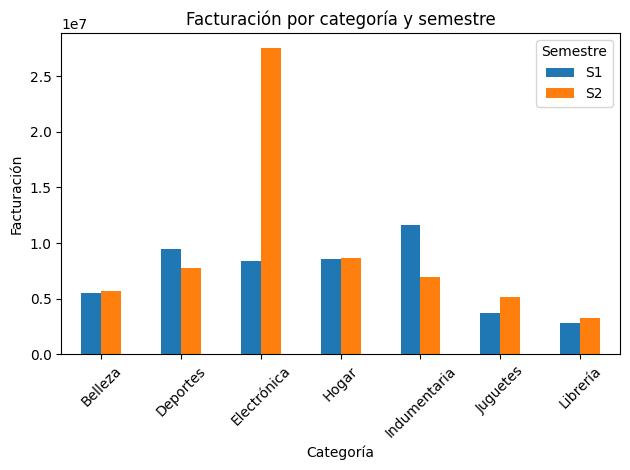

In [ ]:
# Plot de las categorias por mes
categoria_plot = categoria_semestre.pivot(index="categoria",columns="semestre", values="facturacion")

categoria_plot.plot(kind="bar")

plt.title("Facturación por categoría y semestre")
plt.xlabel("Categoría")
plt.ylabel("Facturación")
plt.xticks(rotation=45)
plt.legend(title="Semestre")
plt.tight_layout()
plt.show()
#Hay un salto en electronica rpncipalmente pero tambien en indumentaria pero en menor medida

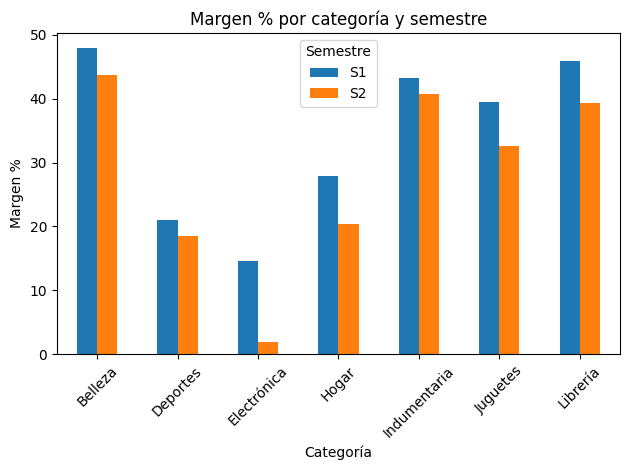

In [ ]:
# Plot de margen
margen_plot = categoria_semestre.pivot(index="categoria", columns="semestre", values="margen_pct")

margen_plot.plot(kind="bar")

plt.title("Margen % por categoría y semestre")
plt.xlabel("Categoría")
plt.ylabel("Margen %")
plt.xticks(rotation=45)
plt.legend(title="Semestre")
plt.tight_layout()
plt.show()

#Principales diferencas ente electronica, seguido por hogar, juguetes

Se ve claramente las diferencias en Electronica, la pregunta es porque?
Algunas hipotesis
- aumentaron mucho los descuentos?
- se vendieron productos electrónicos con menor margen?
- cambió el mix de productos?
- bajó el precio de venta?
- aumentó el costo?

Pasamos a Power BI para contar la historia

Idea general
Página 1: Crecieron las ventas?

- Facturación +30%
- Pedidos +25%
- Unidades +36,8%
- Margen −25%

Página 2: Qué pasó con la rentabilidad?

- Margen % S1 vs. S2
- Margen por categoría
- Facturación por categoría
- Highlight de Electrónica

Página 3: Por qué cayó el margen?
- Descuentos
- Productos
- Precio vs. costo
- Mix